In [45]:
# start by importing the necessary packages
import cv2
import os
import matplotlib.pyplot as plt
import json
import threading
import numpy as np
import matplotlib.cm as cm
from skimage import color, segmentation, measure, morphology, filters
from sklearn.cluster import KMeans
import pandas as pd
import os

# import the detector
from GMMDetector import MaterialDetector
import sys
sys.path.append("../../../src")
from image_container import Image_Container

os.environ["OMERO_HOST"] = "100.125.247.59"
os.environ["OMERO_PORT"] = "4064"
os.environ["OMERO_USERNAME"] = "root"
os.environ["OMERO_PASSWORD"] = "omero"


def showImage(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(img)

image_container = Image_Container()

In [46]:
def whitebalance(image):
    # return image
    result = image.astype(np.float32)
    quantized = (image // 8) * 8
    brightness = quantized.sum(axis=2)
    mask = brightness > 30
    filtered = quantized[mask]
    
    colors_as_int = (filtered[:, 0].astype(np.int32) << 16) | (filtered[:, 1].astype(np.int32) << 8) | filtered[:, 2].astype(np.int32)
    
    counts = np.bincount(colors_as_int)
    most_common_int = np.argmax(counts)
    
    color = np.array([
        (most_common_int >> 16) & 0xFF,
        (most_common_int >> 8) & 0xFF,
        most_common_int & 0xFF
    ], dtype=np.float32)
    
    avg_gray = (color[0] + color[1] + color[2]) / 3.0
    scale_r = avg_gray / color[0] if color[0] > 0 else 1.0
    scale_g = avg_gray / color[1] if color[1] > 0 else 1.0
    scale_b = avg_gray / color[2] if color[2] > 0 else 1.0
    # print(f"Most common color: RGB({color[0]}, {color[1]}, {color[2]})")
    # print(f"Scale factors: R={scale_r:.3f}, G={scale_g:.3f}, B={scale_b:.3f}")
    result[:, :, 0] *= scale_r
    result[:, :, 1] *= scale_g
    result[:, :, 2] *= scale_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

def greyscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [47]:
class FlinderDetector:
    """
    Simplified Flinder flake detection algorithm.
    Uses color-based segmentation with KBGR channels and calibration data.
    """
    
    def __init__(self, calibration_folder=None, use_high_contrast=False):
        """
        Args:
            calibration_folder: Path to folder containing calibration.dat and calibration_details.dat
            use_high_contrast: Whether to apply high contrast enhancement
        """
        self.calibration_folder = calibration_folder
        self.use_high_contrast = use_high_contrast
        
        # Default criteria (can be overridden)
        self.criteria_thresholds = {
            'k_var_max': 15,
            'b_var_max': 15,
            'g_var_max': 15,
            'r_var_max': 15,
            'area_perimeter_ratio_min': 0.05,
            'area_perimeter_ratio_max': 100000,
            'aspect_ratio_min': 1,
            'aspect_ratio_max': 6,
        }
        
        # Channel usage (KBGR)
        self.use_k = 1
        self.use_b = 1
        self.use_g = 1
        self.use_r = 1
        
        # Calibration data
        self.mask_values = None
        self.thickness_cal = None
        self.k_cal = None
        self.b_cal = None
        self.g_cal = None
        self.r_cal = None
        
    def high_contrast(self, image):
        """Apply high contrast enhancement to image."""
        MID_SPECTRUM_VALUE = 255. / 2.
        spread = 20
        
        def filter_extreme_values(v):
            v = v.astype(np.float32)
            liminf = MID_SPECTRUM_VALUE - spread
            limsup = MID_SPECTRUM_VALUE + spread
            mid = MID_SPECTRUM_VALUE
            
            # Linear transformation for values below mid
            a = mid / (mid - liminf)
            b = -a * liminf
            cond = v < mid
            v[cond] = a * v[cond] + b
            
            # Linear transformation for values above mid
            a = (mid - 255) / (mid - limsup)
            b = 255 - a * limsup
            cond = v > mid
            v[cond] = a * v[cond] + b
            
            v = np.clip(v, 0, 255)
            return v.astype(np.uint8)
        
        b, g, r = cv2.split(image)
        b_hc = filter_extreme_values(b)
        g_hc = filter_extreme_values(g)
        r_hc = filter_extreme_values(r)
        
        image_hc = cv2.merge((b_hc, g_hc, r_hc))
        image_hc = cv2.medianBlur(image_hc, 11)
        
        return image_hc
    
    def extract_kbgr(self, image):
        """Extract K (gray), B (blue), G (green), R (red) channels."""
        b, g, r = cv2.split(image)
        k = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return k.astype("uint8"), b.astype("uint8"), g.astype("uint8"), r.astype("uint8")
    
    def create_mask(self, channel, lmin, lmax):
        """Create binary mask for a single channel.
        Returns 255 for pixels where lmin <= value <= lmax, 0 otherwise.
        """
        square = 5
        blurred = cv2.blur(channel, (square, square))
        
        # Use inRange for clearer and correct range selection
        # This selects pixels where value is between lmin and lmax (inclusive)
        mask = cv2.inRange(blurred, lmin, lmax)
        
        return mask
    
    def make_selection(self, k, b, g, r, mask_values):
        """
        Create combined mask based on KBGR channel thresholds.
        
        Args:
            k, b, g, r: Individual channel images
            mask_values: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
        """
        kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax = mask_values
        
        # Start with K channel mask (or all white if K not used)
        if self.use_k == 1:
            gray_mask = self.create_mask(k, kmin, kmax)
        else:
            gray_mask = np.ones(k.shape, dtype=np.uint8) * 255
        
        # Apply other channels with AND operation (bitwise_and)
        if self.use_b == 1:
            blue_mask = self.create_mask(b, bmin, bmax)
            gray_mask = cv2.bitwise_and(gray_mask, blue_mask)
        
        if self.use_g == 1:
            green_mask = self.create_mask(g, gmin, gmax)
            gray_mask = cv2.bitwise_and(gray_mask, green_mask)
        
        if self.use_r == 1:
            red_mask = self.create_mask(r, rmin, rmax)
            gray_mask = cv2.bitwise_and(gray_mask, red_mask)
        
        # Apply median blur to reduce noise
        gray_mask = cv2.medianBlur(gray_mask, 5)
        
        return gray_mask
    
    def find_contours_in_mask(self, mask, min_area=100):
        """Find contours in binary mask above minimum area."""
        contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        
        large_contours = []
        for contour in contours:
            if cv2.contourArea(contour) > min_area:
                large_contours.append(contour)
        
        return large_contours
    
    def calculate_contour_statistics(self, contour, k, b, g, r):
        """Calculate color and geometric statistics for a contour."""
        # Create mask for this contour
        mask = np.zeros(k.shape, np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        
        # Extract values within mask
        k_vals = k[mask > 0.5]
        b_vals = b[mask > 0.5]
        g_vals = g[mask > 0.5]
        r_vals = r[mask > 0.5]
        
        # Calculate median and standard deviation
        k_median, k_std = np.median(k_vals), np.std(k_vals)
        b_median, b_std = np.median(b_vals), np.std(b_vals)
        g_median, g_std = np.median(g_vals), np.std(g_vals)
        r_median, r_std = np.median(r_vals), np.std(r_vals)
        
        # Calculate geometric properties
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        if area == 0: area = 1
        if perimeter == 0: perimeter = 1
        
        area_perimeter_ratio = 16 * area / (perimeter * perimeter)
        
        # Calculate aspect ratio using minimum area rectangle
        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect)
        
        dim1 = np.linalg.norm(box[0] - box[1])
        dim2 = np.linalg.norm(box[1] - box[2])
        
        if dim1 == 0: dim1 = 1
        if dim2 == 0: dim2 = 1
        
        aspect_ratio = max(dim1, dim2) / min(dim1, dim2)
        
        return {
            'k_median': k_median, 'k_std': k_std,
            'b_median': b_median, 'b_std': b_std,
            'g_median': g_median, 'g_std': g_std,
            'r_median': r_median, 'r_std': r_std,
            'area': area,
            'perimeter': perimeter,
            'area_perimeter_ratio': area_perimeter_ratio,
            'aspect_ratio': aspect_ratio,
        }
    
    def check_criteria(self, stats):
        """Check if contour statistics meet criteria thresholds."""
        checks = [
            stats['k_std'] < self.criteria_thresholds['k_var_max'],
            stats['b_std'] < self.criteria_thresholds['b_var_max'],
            stats['g_std'] < self.criteria_thresholds['g_var_max'],
            stats['r_std'] < self.criteria_thresholds['r_var_max'],
            stats['area_perimeter_ratio'] > self.criteria_thresholds['area_perimeter_ratio_min'],
            stats['area_perimeter_ratio'] < self.criteria_thresholds['area_perimeter_ratio_max'],
            stats['aspect_ratio'] > self.criteria_thresholds['aspect_ratio_min'],
            stats['aspect_ratio'] < self.criteria_thresholds['aspect_ratio_max'],
        ]
        return all(checks)
    
    def check_color_in_range(self, stats, mask_values):
        """Check if color values are within calibrated ranges."""
        kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax = mask_values
        
        checks = []
        if self.use_k == 1:
            checks.append(kmin < stats['k_median'] < kmax)
        if self.use_b == 1:
            checks.append(bmin < stats['b_median'] < bmax)
        if self.use_g == 1:
            checks.append(gmin < stats['g_median'] < gmax)
        if self.use_r == 1:
            checks.append(rmin < stats['r_median'] < rmax)
        
        return all(checks)
    
    def detect_flakes(self, image, mask_values_list, min_area=100):
        """
        Main detection function.
        
        Args:
            image: BGR image (as read by cv2.imread)
            mask_values_list: List of mask values for different thickness ranges
                Each element: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
            min_area: Minimum contour area in pixels
        
        Returns:
            List of detected flakes with their properties
        """
        # Preprocess image
        if self.use_high_contrast:
            image_processed = self.high_contrast(image)
            image_processed = cv2.medianBlur(image_processed, 7)
        else:
            image_processed = cv2.medianBlur(image, 7)
        
        # Extract channels
        k, b, g, r = self.extract_kbgr(image_processed)
        
        # Also keep original channels for final measurements
        k_orig, b_orig, g_orig, r_orig = self.extract_kbgr(image)
        
        # Detect contours for each thickness interval
        all_flakes = []
        
        for interval_idx, mask_values in enumerate(mask_values_list):
            # Create mask for this thickness interval
            mask = self.make_selection(k, b, g, r, mask_values)
            
            # Find contours
            contours = self.find_contours_in_mask(mask, min_area)
            
            # Analyze each contour
            for contour in contours:
                # Calculate statistics using original (non-contrast-enhanced) image
                stats = self.calculate_contour_statistics(contour, k_orig, b_orig, g_orig, r_orig)
                
                # Check criteria
                if not self.check_criteria(stats):
                    continue
                
                # Check color in range
                if not self.check_color_in_range(stats, mask_values):
                    continue
                
                # Get center position
                M = cv2.moments(contour)
                if M['m00'] > 0:
                    cx = int(M['m10'] / M['m00'])
                    cy = int(M['m01'] / M['m00'])
                else:
                    cx, cy = 0, 0
                
                # Store flake information
                flake = {
                    'contour': contour,
                    'interval_idx': interval_idx,
                    'center': (cx, cy),
                    'stats': stats,
                    'mask_values': mask_values,
                }
                
                all_flakes.append(flake)
        
        return all_flakes
    
    def visualize_flakes(self, image, flakes, show_stats=True):
        """
        Visualize detected flakes on image.
        
        Args:
            image: Original BGR image
            flakes: List of detected flakes from detect_flakes()
            show_stats: Whether to draw statistics on image
        
        Returns:
            Image with flakes outlined and labeled
        """
        vis_image = image.copy()
        
        # Generate colors for different thickness intervals
        max_interval = max([f['interval_idx'] for f in flakes]) if flakes else 0
        colors = cm.rainbow(np.linspace(0, 1, max_interval + 1))[:, :3] * 255
        
        for idx, flake in enumerate(flakes):
            color = colors[flake['interval_idx']].astype(int).tolist()
            
            # Draw contour
            cv2.drawContours(vis_image, [flake['contour']], -1, color, 2)
            
            # Draw center point
            cv2.circle(vis_image, flake['center'], 5, color, -1)
            
            # Draw label
            if show_stats:
                label = f"{idx}: A={int(flake['stats']['area'])}"
                cv2.putText(vis_image, label, 
                           (flake['center'][0] + 10, flake['center'][1]), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                cv2.putText(vis_image, label, 
                           (flake['center'][0] + 10, flake['center'][1]), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        
        return vis_image


In [48]:
# Calculate mask values from monolayer RGB color
# Monolayer RGB: (160, 166, 166)
monolayer_rgb = (160, 166, 166)  # R, G, B
r_target, g_target, b_target = monolayer_rgb

# Convert RGB to BGR (OpenCV format)
b_target_bgr = b_target
g_target_bgr = g_target
r_target_bgr = r_target

# Calculate K (grayscale) from RGB using OpenCV's formula
# K = 0.299*R + 0.587*G + 0.114*B
k_target = int(0.299 * r_target + 0.587 * g_target + 0.114 * b_target)

print(f"Target monolayer color:")
print(f"  RGB: ({r_target}, {g_target}, {b_target})")
print(f"  BGR: ({b_target_bgr}, {g_target_bgr}, {r_target_bgr})")
print(f"  K (grayscale): {k_target}")

# Define tolerance ranges for each channel
# Adjust these values based on how much variation you expect
tolerance_k = 15  # ±15 for grayscale
tolerance_b = 15  # ±15 for blue
tolerance_g = 15  # ±15 for green
tolerance_r = 15  # ±15 for red

# Calculate mask value ranges [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
mask_values_monolayer = [
    max(0, k_target - tolerance_k),      # kmin
    min(255, k_target + tolerance_k),      # kmax
    max(0, b_target_bgr - tolerance_b),   # bmin
    min(255, b_target_bgr + tolerance_b), # bmax
    max(0, g_target_bgr - tolerance_g),   # gmin
    min(255, g_target_bgr + tolerance_g), # gmax
    max(0, r_target_bgr - tolerance_r),   # rmin
    min(255, r_target_bgr + tolerance_r), # rmax
]

print(f"\nCalculated mask values for monolayer:")
print(f"  Format: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]")
print(f"  Values: {mask_values_monolayer}")
print(f"\n  K range: [{mask_values_monolayer[0]}, {mask_values_monolayer[1]}]")
print(f"  B range: [{mask_values_monolayer[2]}, {mask_values_monolayer[3]}]")
print(f"  G range: [{mask_values_monolayer[4]}, {mask_values_monolayer[5]}]")
print(f"  R range: [{mask_values_monolayer[6]}, {mask_values_monolayer[7]}]")

# Store for use in detection
monolayer_mask_values = mask_values_monolayer


Target monolayer color:
  RGB: (160, 166, 166)
  BGR: (166, 166, 160)
  K (grayscale): 164

Calculated mask values for monolayer:
  Format: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
  Values: [156, 172, 158, 174, 158, 174, 152, 168]

  K range: [156, 172]
  B range: [158, 174]
  G range: [158, 174]
  R range: [152, 168]

Note: Using tighter tolerance (±8) to avoid detecting entire screen.
      Adjust tolerance values if needed based on actual image colors.


In [49]:
# Diagnostic: Check actual colors in an image after white balance
# This helps verify if white balance is shifting the colors

# Load a test image
test_image_path = "images/image4.png"
if os.path.exists(test_image_path):
    test_image_bgr = cv2.imread(test_image_path, cv2.IMREAD_COLOR)
    test_image_rgb = cv2.cvtColor(test_image_bgr, cv2.COLOR_BGR2RGB)
    test_image_wb = whitebalance(test_image_rgb)
    test_image_wb_bgr = cv2.cvtColor(test_image_wb, cv2.COLOR_RGB2BGR)
    
    # Extract KBGR channels
    k, b, g, r = cv2.split(test_image_wb_bgr)
    k_channel = cv2.cvtColor(test_image_wb_bgr, cv2.COLOR_BGR2GRAY)
    
    # Sample some pixels (you can adjust these coordinates)
    sample_y, sample_x = 500, 500  # Center-ish area
    if sample_y < test_image_wb_bgr.shape[0] and sample_x < test_image_wb_bgr.shape[1]:
        print(f"Sample pixel at ({sample_x}, {sample_y}):")
        print(f"  BGR: ({b[sample_y, sample_x]}, {g[sample_y, sample_x]}, {r[sample_y, sample_x]})")
        print(f"  RGB: ({r[sample_y, sample_x]}, {g[sample_y, sample_x]}, {b[sample_y, sample_x]})")
        print(f"  K (grayscale): {k_channel[sample_y, sample_x]}")
        print(f"\nTarget monolayer:")
        print(f"  BGR: ({b_target_bgr}, {g_target_bgr}, {r_target_bgr})")
        print(f"  RGB: ({r_target_bgr}, {g_target_bgr}, {b_target_bgr})")
        print(f"  K: {k_target}")
        
        # Check if pixel is in range
        k_val = k_channel[sample_y, sample_x]
        b_val = b[sample_y, sample_x]
        g_val = g[sample_y, sample_x]
        r_val = r[sample_y, sample_x]
        
        print(f"\nIn range check:")
        print(f"  K: {mask_values_monolayer[0]} <= {k_val} <= {mask_values_monolayer[1]}? {mask_values_monolayer[0] <= k_val <= mask_values_monolayer[1]}")
        print(f"  B: {mask_values_monolayer[2]} <= {b_val} <= {mask_values_monolayer[3]}? {mask_values_monolayer[2] <= b_val <= mask_values_monolayer[3]}")
        print(f"  G: {mask_values_monolayer[4]} <= {g_val} <= {mask_values_monolayer[5]}? {mask_values_monolayer[4] <= g_val <= mask_values_monolayer[5]}")
        print(f"  R: {mask_values_monolayer[6]} <= {r_val} <= {mask_values_monolayer[7]}? {mask_values_monolayer[6] <= r_val <= mask_values_monolayer[7]}")
else:
    print(f"Test image {test_image_path} not found. Skipping diagnostic.")


ValueError: not enough values to unpack (expected 4, got 3)

Running Flinder detection algorithm...
Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 252 px
  Aspect ratio: 1.26
  KBGR median: (152, 152, 153, 149)
  KBGR std: (1.1, 1.9, 2.0, 2.0)

Flake 1:
  Thickness interval: 0
  Area: 232 px
  Aspect ratio: 1.88
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.3, 2.3, 2.3, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 2847556 px
  Aspect ratio: 1.35
  KBGR median: (168, 167, 170, 164)
  KBGR std: (8.2, 7.6, 9.8, 10.3)


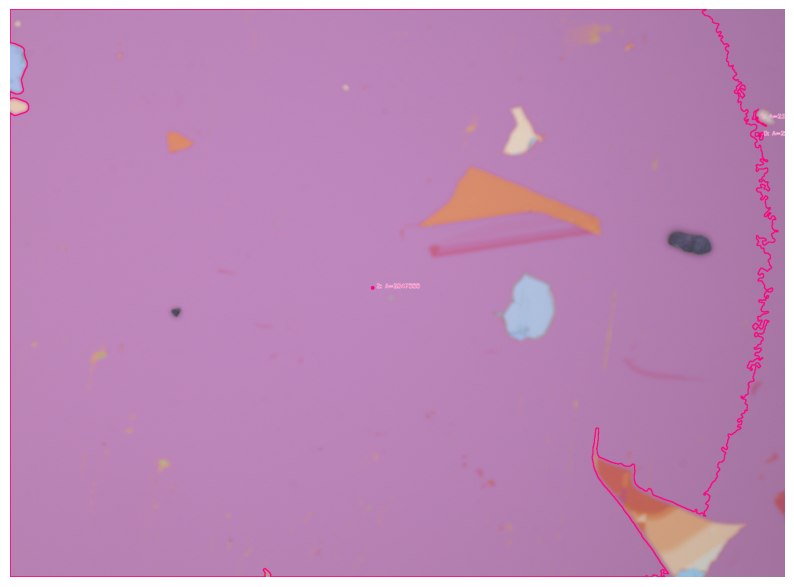

In [ ]:
# Test the Flinder detector with calculated mask values

# Create detector instance
detector = FlinderDetector(use_high_contrast=False)

# Use calculated monolayer mask values from cell 3
# Format: [kmin, kmax, bmin, bmax, gmin, gmax, rmin, rmax]
mask_values_list = [
    monolayer_mask_values,  # Monolayer - calculated from RGB(160, 166, 166)
]

# Detect flakes
print("Running Flinder detection algorithm...")
flakes = detector.detect_flakes(image, mask_values_list, min_area=200)
print(f"Found {len(flakes)} flakes")

# Visualize results
vis_image = detector.visualize_flakes(image_copy, flakes)

# Print details of detected flakes
for idx, flake in enumerate(flakes):
    stats = flake['stats']
    print(f"\nFlake {idx}:")
    print(f"  Thickness interval: {flake['interval_idx']}")
    print(f"  Area: {stats['area']:.0f} px")
    print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
    print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
          f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
    print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
          f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")

showImage(vis_image)



Processing image4.png
Running Flinder detection algorithm...
Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 252 px
  Aspect ratio: 1.26
  KBGR median: (152, 152, 153, 149)
  KBGR std: (1.1, 1.9, 2.0, 2.0)

Flake 1:
  Thickness interval: 0
  Area: 232 px
  Aspect ratio: 1.88
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.3, 2.3, 2.3, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 2847556 px
  Aspect ratio: 1.35
  KBGR median: (168, 167, 170, 164)
  KBGR std: (8.2, 7.6, 9.8, 10.3)

Displaying visualization for image4.png:


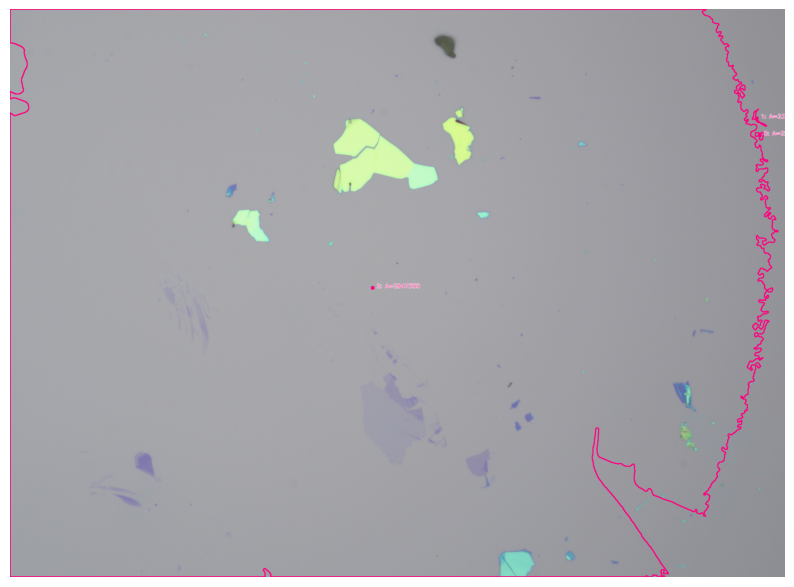


Processing image5.png
Running Flinder detection algorithm...
Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 252 px
  Aspect ratio: 1.26
  KBGR median: (152, 152, 153, 149)
  KBGR std: (1.1, 1.9, 2.0, 2.0)

Flake 1:
  Thickness interval: 0
  Area: 232 px
  Aspect ratio: 1.88
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.3, 2.3, 2.3, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 2847556 px
  Aspect ratio: 1.35
  KBGR median: (168, 167, 170, 164)
  KBGR std: (8.2, 7.6, 9.8, 10.3)

Displaying visualization for image5.png:


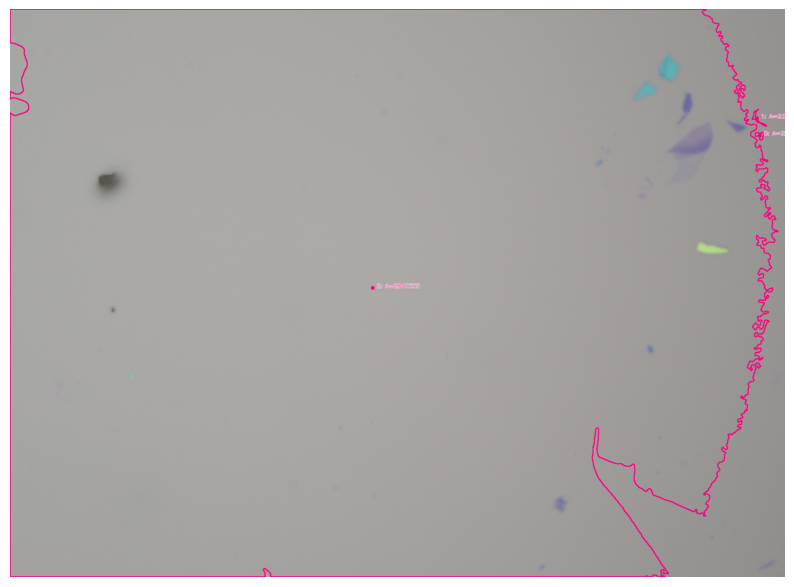


Processing image6.png
Running Flinder detection algorithm...
Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 252 px
  Aspect ratio: 1.26
  KBGR median: (152, 152, 153, 149)
  KBGR std: (1.1, 1.9, 2.0, 2.0)

Flake 1:
  Thickness interval: 0
  Area: 232 px
  Aspect ratio: 1.88
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.3, 2.3, 2.3, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 2847556 px
  Aspect ratio: 1.35
  KBGR median: (168, 167, 170, 164)
  KBGR std: (8.2, 7.6, 9.8, 10.3)

Displaying visualization for image6.png:


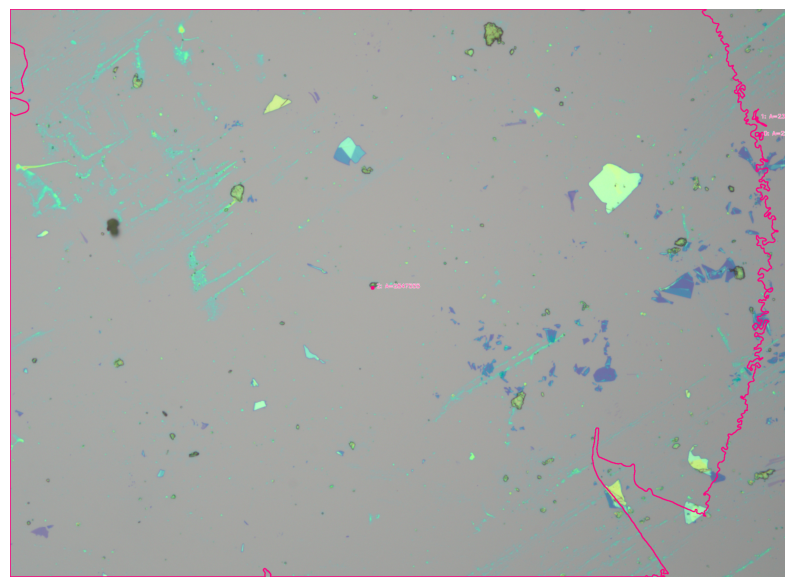


Processing image7.png
Running Flinder detection algorithm...
Found 3 flakes

Flake 0:
  Thickness interval: 0
  Area: 252 px
  Aspect ratio: 1.26
  KBGR median: (152, 152, 153, 149)
  KBGR std: (1.1, 1.9, 2.0, 2.0)

Flake 1:
  Thickness interval: 0
  Area: 232 px
  Aspect ratio: 1.88
  KBGR median: (151, 152, 153, 149)
  KBGR std: (1.3, 2.3, 2.3, 2.1)

Flake 2:
  Thickness interval: 0
  Area: 2847556 px
  Aspect ratio: 1.35
  KBGR median: (168, 167, 170, 164)
  KBGR std: (8.2, 7.6, 9.8, 10.3)

Displaying visualization for image7.png:


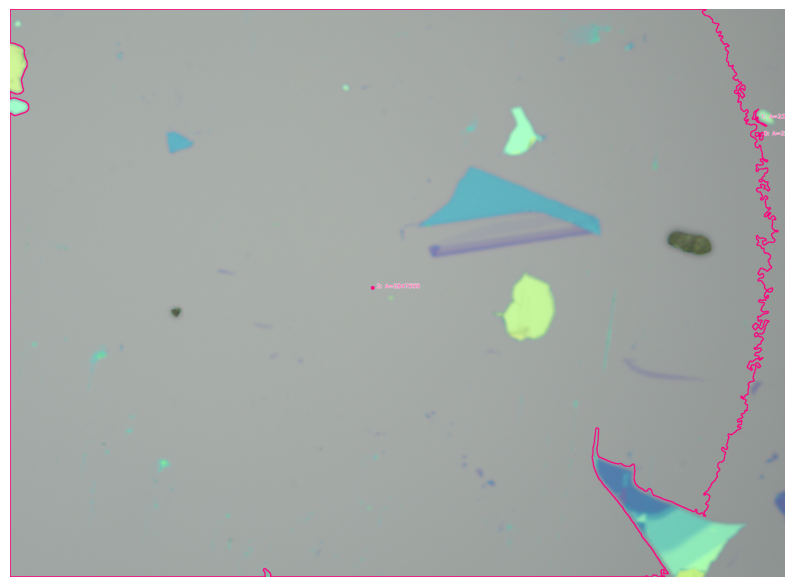

In [ ]:
# Process and visualize images 4-7 on every run
images_dir = "images"
image_numbers = [4, 5, 6, 7]

# Create detector instance
detector = FlinderDetector(use_high_contrast=False)

# Use calculated monolayer mask values from cell 3
mask_values_list = [
    monolayer_mask_values,  # Monolayer - calculated from RGB(160, 166, 166)
]

# Process each image
for img_num in image_numbers:
    image_path = os.path.join(images_dir, f"imageW{img_num}.png")
    
    if not os.path.exists(image_path):
        print(f"Warning: {image_path} not found, skipping...")
        continue
    
    print(f"\n{'='*60}")
    print(f"Processing image{img_num}.png")
    print(f"{'='*60}")
    
    # Load image
    image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        print(f"Error: Could not load {image_path}")
        continue
    
    # Convert BGR to RGB for display
    image = whitebalance(image_bgr)
    
    # Detect flakes
    print("Running Flinder detection algorithm...")
    flakes = detector.detect_flakes(image_bgr_processed, mask_values_list, min_area=200)
    print(f"Found {len(flakes)} flakes")
    
    # Visualize results on original image (convert to BGR for visualization function)
    vis_image= detector.visualize_flakes(image, flakes)
    
    # Print details of detected flakes
    for idx, flake in enumerate(flakes):
        stats = flake['stats']
        print(f"\nFlake {idx}:")
        print(f"  Thickness interval: {flake['interval_idx']}")
        print(f"  Area: {stats['area']:.0f} px")
        print(f"  Aspect ratio: {stats['aspect_ratio']:.2f}")
        print(f"  KBGR median: ({stats['k_median']:.0f}, {stats['b_median']:.0f}, "
              f"{stats['g_median']:.0f}, {stats['r_median']:.0f})")
        print(f"  KBGR std: ({stats['k_std']:.1f}, {stats['b_std']:.1f}, "
              f"{stats['g_std']:.1f}, {stats['r_std']:.1f})")
    
    # Display visualization
    print(f"\nDisplaying visualization for image{img_num}.png:")
    showImage(vis_image)
    plt.show()
